In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۵: کاربردها و چالش‌ها

In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

K-Nearest Neighbors جذاب است زیرا می‌تواند با تشریفات کمِ ساخت مدل با الگوهای محلی سازگار شود. این روش در بازیابی شبیه توصیه، شباهت تصویر و متن، تشخیص ناهنجاری، طبقه‌بندی جغرافیایی، پشتیبانی تصمیم پزشکی، بخش‌بندی مشتری و baseline عملی برای مسئله‌های جدولی کاربرد دارد. اما روشی که در نوت‌بوک زیبا کار می‌کند، وقتی فاصله با دامنه سازگار نباشد، داده تنک یا جانبدار باشد، کلاس‌ها نامتوازن باشند یا تأخیر پیش‌بینی زیاد شود می‌تواند بی‌صدا شکست بخورد.

در این درس KNN را به‌عنوان یک سامانهٔ کاربردی می‌بینیم، نه فقط الگوریتم. از Fast_Food_Restaurants_US.csv یک مثال برند رستوران بر پایهٔ موقعیت می‌سازیم، مسئله‌های کیفیت دادهٔ واقعی را بررسی می‌کنیم، K را با اعتبارسنجی انتخاب می‌کنیم، همسایه‌های محلی را می‌بینیم و تغییر زمان پیش‌بینی با اندازهٔ دادهٔ آموزش را می‌سنجیم. سپس از diabetes.csv به‌عنوان مثال طبقه‌بندی به‌سبک سلامت استفاده می‌کنیم تا اهمیت معیارهای متوازن و تفسیر مسئولانه روشن شود.

هدف ادعا دربارهٔ شناسایی رستوران یا تشخیص بیمار در تولید نیست. هدف، آموختن پرسش‌هایی است که باید پیش از اعتماد به مدل مبتنی بر فاصله پاسخ داده شوند.

In [3]:
fast_food_path = Path("../../../Datasets/Classification/Fast_Food_Restaurants_US.csv")
fast_food = pd.read_csv(fast_food_path)

display(fast_food.head())
display(fast_food.dtypes.rename("dtype").to_frame())
quality_summary = pd.DataFrame({
    "rows": [len(fast_food)],
    "duplicate_rows": [fast_food.duplicated().sum()],
    "missing_latitude": [fast_food["latitude"].isna().sum()],
    "missing_longitude": [fast_food["longitude"].isna().sum()],
    "unique_restaurant_names": [fast_food["name"].nunique()],
})
display(quality_summary)

,Unnamed: 0,address,categories,city,country,latitude,longitude,name,postalCode,province,websites
0,0,800 N Canal Blvd,American Restaurant and Fast Food Restaurant,Thibodaux,US,29.814697,-90.814742,SONIC Drive In,70301,LA,https://locations.sonicdrivein.com/la/thibodau...
1,1,800 N Canal Blvd,Fast Food Restaurants,Thibodaux,US,29.814697,-90.814742,SONIC Drive In,70301,LA,https://locations.sonicdrivein.com/la/thibodau...
2,2,206 Wears Valley Rd,Fast Food Restaurant,Pigeon Forge,US,35.803788,-83.580553,Taco Bell,37863,TN,"http://www.tacobell.com,https://locations.taco..."
3,3,3652 Parkway,Fast Food,Pigeon Forge,US,35.782339,-83.551408,Arby's,37863,TN,"http://www.arbys.com,https://locations.arbys.c..."
4,4,2118 Mt Zion Parkway,Fast Food Restaurant,Morrow,US,33.562738,-84.321143,Steak 'n Shake,30260,GA,http://www.steaknshake.com/locations/23851-ste...


,dtype
Unnamed: 0,int64
address,object
categories,object
city,object
country,object
latitude,float64
longitude,float64
name,object
postalCode,object
province,object


,rows,duplicate_rows,missing_latitude,missing_longitude,unique_restaurant_names
0,10000,0,0,0,571


### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. چند الگوی کاربردی مفید KNN را نام ببرید و تشخیص دهید چه زمانی شباهت محلی معنادار است.
2. یک مجموعه‌دادهٔ واقعی ناقص را به کاربرد کوچک و آزمون‌پذیر KNN تبدیل کنید.
3. پیش از مدل‌سازی مقادیر گمشده، تکرارها، تعداد دسته‌ها و توازن کلاس را بررسی کنید.
4. با pipeline و اعتبارسنجی متقابل K را بدون نشت آزمون انتخاب کنید.
5. همسایه‌های محلی را به‌عنوان توضیح مدل، نه شواهد علّی، تفسیر کنید.
6. چالش زمان پیش‌بینی روش‌های مبتنی بر نمونه را اندازه بگیرید.
7. دقت عادی را با balanced accuracy و macro F1 مقایسه کنید.
8. خطرهای حریم خصوصی، انصاف، drift و نمایش داده را در کاربردهای مبتنی بر شباهت تشخیص دهید.

پرسش عملی فقط این نیست که مدل می‌تواند پیش‌بینی کند یا نه. باید دید قانون شباهت، داده، معیار عملکرد و شرایط کارکرد، تصمیمی مفید و مسئولانه را پشتیبانی می‌کنند یا نه.

,selected_brand
0,McDonald's
1,Taco Bell


,count
name,
Taco Bell,600
McDonald's,600


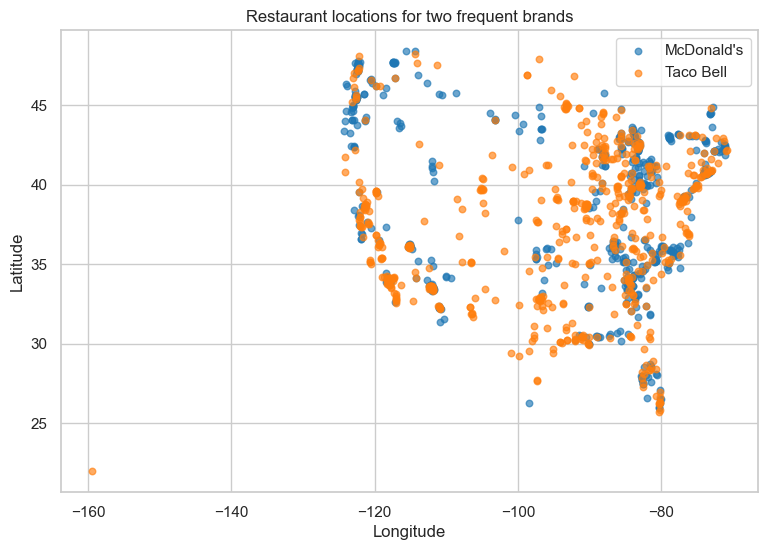

In [4]:
location_ready = fast_food.dropna(subset=["name", "latitude", "longitude", "province"]).copy()
top_brands = location_ready["name"].value_counts().head(2).index.tolist()
restaurant_data = location_ready[location_ready["name"].isin(top_brands)].drop_duplicates(subset=["name", "latitude", "longitude"]).groupby("name", group_keys=False).head(600).copy()
restaurant_X = restaurant_data[["latitude", "longitude", "province"]]
restaurant_y = restaurant_data["name"]

display(pd.DataFrame({"selected_brand": top_brands}))
display(restaurant_y.value_counts().rename("count").to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
for brand, color in zip(top_brands, ["tab:blue", "tab:orange"]):
    subset = restaurant_data[restaurant_data["name"] == brand]
    ax.scatter(subset["longitude"], subset["latitude"], s=22, alpha=0.65, label=brand, color=color)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Restaurant locations for two frequent brands")
ax.legend()
plt.show()

## ۱. KNN کجا مفید است؟

KNN زمانی مناسب است که مثال‌های مرتبط باید مستقیماً بر مورد جدید اثر بگذارند. در بازیابی تصویر، embeddingهای مشابه تصویرهای بصری مرتبط را می‌آورند. در توصیه، کاربران یا آیتم‌های مشابه نامزد پیشنهاد می‌دهند. در تقلب و ناهنجاری، نقطهٔ دور از همسایه‌ها ممکن است نیازمند بازبینی باشد. در کاربردهای جغرافیایی، مکان‌های نزدیک ساختار منطقه‌ای مشترک دارند. در پزشکی، بیمار با پرونده‌های تاریخی مشابه مقایسه می‌شود، هرچند این کار به محافظ‌های قوی و اعتبارسنجی بالینی نیاز دارد.

ماهیت محلی KNN برای اکتشاف نیز مفید است. می‌تواند خوشه‌ها، ناسازگاری برچسب و مثال‌های غیرعادی را بدون تعهد به یک فرم تابع سراسری آشکار کند. baseline خوبی است زیرا فرض‌هایش دیده می‌شوند: نمایش ویژگی، فاصله، K و بازرسی همسایه‌ها را انتخاب کنید.

اما همین شفافیت چالش‌ها را آشکار می‌کند. شباهت خودبه‌خود انصاف، علیت یا سودمندی نیست. مدل ممکن است proxyهای جغرافیایی متغیرهای اجتماعی-اقتصادی را یاد بگیرد، برچسب‌های تاریخی جانبداری داشته باشند و مشاهدهٔ ظاهراً نزدیک از نظر بالینی نامرتبط باشد. KNN باید پشتیبان تحلیل محتاطانه باشد، نه جایگزین قضاوت.

,k,mean_balanced_accuracy,std_balanced_accuracy
4,9,0.683,0.020
3,7,0.681,0.019
5,11,0.681,0.022
7,15,0.678,0.017
6,13,0.677,0.021
2,5,0.676,0.025
1,3,0.662,0.014
0,1,0.647,0.031


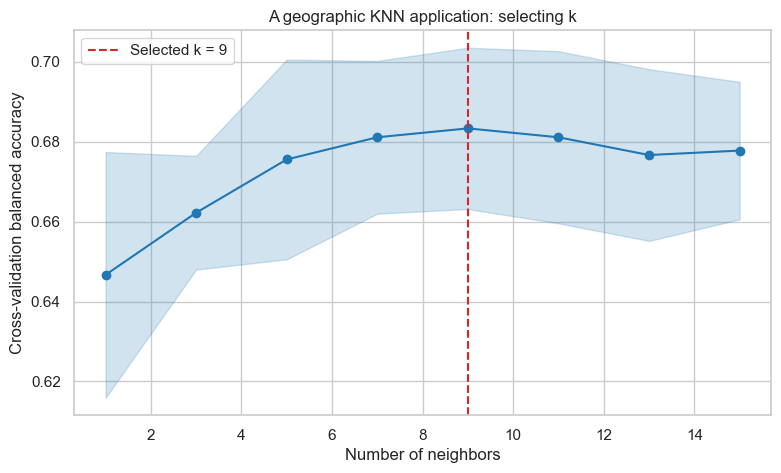

In [5]:
restaurant_X_train, restaurant_X_test, restaurant_y_train, restaurant_y_test = train_test_split(
    restaurant_X, restaurant_y, test_size=0.25, stratify=restaurant_y, random_state=RANDOM_STATE
)
geo_preprocessor = ColumnTransformer([
    ("coordinates", StandardScaler(), ["latitude", "longitude"]),
    ("province", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["province"]),
], sparse_threshold=0)
restaurant_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_rows = []

for k_value in range(1, 16, 2):
    candidate = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=k_value, weights="distance"))
    scores = cross_val_score(candidate, restaurant_X_train, restaurant_y_train, cv=restaurant_cv, scoring="balanced_accuracy", error_score="raise")
    k_rows.append({"k": k_value, "mean_balanced_accuracy": scores.mean(), "std_balanced_accuracy": scores.std()})

k_results = pd.DataFrame(k_rows)
selected_k = int(k_results.loc[k_results["mean_balanced_accuracy"].idxmax(), "k"])
display(k_results.sort_values("mean_balanced_accuracy", ascending=False).head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_results["k"], k_results["mean_balanced_accuracy"], marker="o", color="tab:blue")
ax.fill_between(k_results["k"], k_results["mean_balanced_accuracy"] - k_results["std_balanced_accuracy"], k_results["mean_balanced_accuracy"] + k_results["std_balanced_accuracy"], color="tab:blue", alpha=0.2)
ax.axvline(selected_k, color="tab:red", linestyle="--", label=f"Selected k = {selected_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation balanced accuracy")
ax.set_title("A geographic KNN application: selecting k")
ax.legend()
plt.show()

## ۲. مثال کاربردی: طبقه‌بندی برند رستوران از موقعیت

فایل fast-food نام، مکان، دسته‌ها، اطلاعات پستی، وب‌سایت و رکوردهای تکراری دارد. سطرهای نخست و نوع داده‌ها پیش از ساخت هر چیز بررسی می‌شوند. برای مثال فشرده و بازتولیدپذیر، دو نام رستوران پرتکرار با مختصات و province معتبر را انتخاب می‌کنیم. latitude، longitude و province ویژگی‌اند و نام رستوران هدف است.

این عمداً نمایش محدودی است. موقعیت به تمایز برند کمک می‌کند زیرا زنجیره‌ها اثر منطقه‌ای دارند، اما تصمیم‌های تاریخی کسب‌وکار را نیز کدگذاری می‌کند و اگر مکان‌های تکراری میان تقسیم‌ها نشت کنند عملکرد را بیش از حد خوب نشان می‌دهد. تکرارهای دقیق نام و مختصات را حذف می‌کنیم، تقسیم stratified می‌گیریم و تفسیر را محدود نگه می‌داریم: این کاربرد شباهت جغرافیایی است، نه خدمت عمومی شناسایی رستوران.

,metric,test_value
0,accuracy,0.71
1,balanced_accuracy,0.71


,precision,recall,f1-score,support
McDonald's,0.686,0.773,0.727,150.00
Taco Bell,0.740,0.647,0.690,150.00
accuracy,0.710,0.710,0.710,0.71
macro avg,0.713,0.710,0.709,300.00
weighted avg,0.713,0.710,0.709,300.00


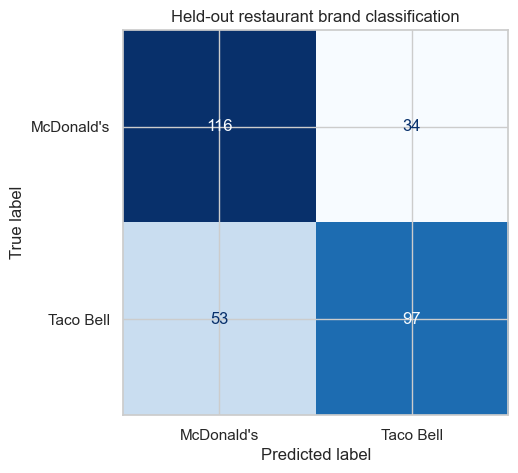

In [6]:
restaurant_model = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=selected_k, weights="distance"))
restaurant_model.fit(restaurant_X_train, restaurant_y_train)
restaurant_prediction = restaurant_model.predict(restaurant_X_test)

display(pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy"],
    "test_value": [accuracy_score(restaurant_y_test, restaurant_prediction), balanced_accuracy_score(restaurant_y_test, restaurant_prediction)],
}).round(3))
display(pd.DataFrame(classification_report(restaurant_y_test, restaurant_prediction, output_dict=True, zero_division=0)).T.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(restaurant_y_test, restaurant_prediction, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out restaurant brand classification")
plt.show()

## ۳. کیفیت داده بخشی از مدل KNN است

روش‌های فاصله به کیفیت داده بسیار حساس‌اند، زیرا هر ویژگی مستقیم در هندسهٔ همسایگی شرکت می‌کند. مختصات گمشده، فهرست‌های تکراری کسب‌وکار، املای ناهماهنگ برند، دسته‌های پُرتعداد و مکان‌های قدیمی همسایه‌های نزدیک را عوض می‌کنند. درخت یا مدل خطی نیز آسیب می‌بیند، اما KNN ساختار سراسری یادگرفته‌شده‌ای ندارد که خطاها را میانگین کند.

پیش از انتخاب زیرمجموعهٔ کاربرد، تکرارها و مقدارهای مکان گمشده را بررسی می‌کنیم. province به صورت one-hot و latitude و longitude استاندارد می‌شوند. استانداردسازی مختصات در این مثال تصمیم مدل‌سازی است، نه مدل کامل فاصلهٔ جغرافیایی. برای گسترهٔ بزرگ جغرافیایی، great-circle distance مناسب‌تر است. نکته این است که فرض فاصله صریح و آزمون‌پذیر شود.

In [7]:
query_row = restaurant_X_test.iloc[[0]]
query_transformed = restaurant_model.named_steps["columntransformer"].transform(query_row)
neighbor_distances, neighbor_indices = restaurant_model.named_steps["kneighborsclassifier"].kneighbors(query_transformed)
neighbor_table = restaurant_X_train.iloc[neighbor_indices[0]].copy()
neighbor_table["brand"] = restaurant_y_train.iloc[neighbor_indices[0]].to_numpy()
neighbor_table["distance"] = neighbor_distances[0]

display(query_row.assign(predicted_brand=restaurant_model.predict(query_row), actual_brand=restaurant_y_test.iloc[0]))
display(neighbor_table.sort_values("distance").round(3))

,latitude,longitude,province,predicted_brand,actual_brand
1580,38.577614,-121.549103,CA,McDonald's,Taco Bell


,latitude,longitude,province,brand,distance
585,38.581,-121.531,CA,McDonald's,0.001
584,38.597,-121.416,CA,McDonald's,0.009
4284,38.598,-121.266,CA,Taco Bell,0.018
5107,38.475,-121.448,CA,Taco Bell,0.022
595,38.677,-121.751,CA,McDonald's,0.023
1605,38.707,-121.313,CA,Taco Bell,0.030
1577,38.746,-121.226,CA,Taco Bell,0.039
2410,38.760,-121.311,CA,Taco Bell,0.040
5109,38.345,-120.771,CA,Taco Bell,0.067


## ۴. K را با اعتبارسنجی انتخاب و سپس یک‌بار ارزیابی کنید

K را با اعتبارسنجی متقابل stratified روی بخش آموزش و با balanced accuracy انتخاب می‌کنیم. balanced accuracy recall دو برند منتخب را میانگین می‌گیرد، پس برند پرتکرار صرفاً با فراوانی نمی‌تواند امتیاز را غالب کند. مجموعهٔ آزمون تا ارزیابی یک‌بارهٔ pipeline منتخب دست‌نخورده می‌ماند.

این جریان همان انضباط درس‌های پیشین است، اما کاربردها اهمیتش را روشن‌تر می‌کنند. اگر برند در مکان‌های یکسان تکرار شود یا تقسیم آموزش-آزمون خوشه‌های منطقه‌ای را نامتوازن بگیرد، یک امتیاز آزمون می‌تواند گمراه‌کننده باشد. اعتبارسنجی متقابل جادو نیست، اما مقایسه را در چند تقسیم آموزش-اعتبارسنجی تکرار می‌کند.

,training_rows,prediction_time_ms_for_batch
0,100,12.068
1,250,10.447
2,500,16.920
3,900,12.198


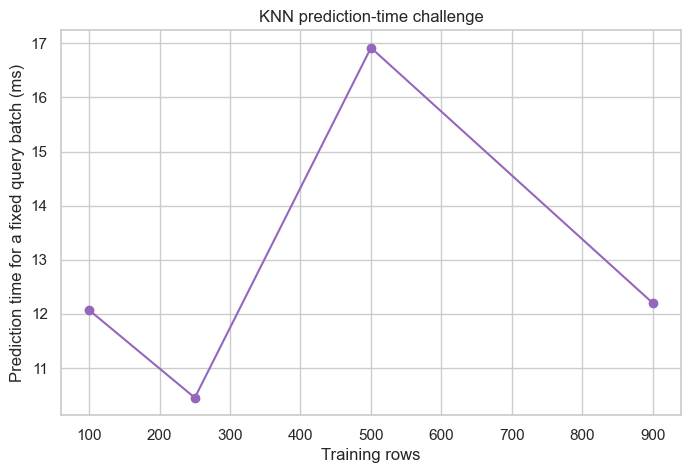

In [8]:
sample_sizes = sorted(set([min(len(restaurant_X_train), value) for value in [100, 250, 500, 1000, 2000]]))
timing_rows = []
for sample_size in sample_sizes:
    sample_X = restaurant_X_train.sample(n=sample_size, random_state=RANDOM_STATE)
    sample_y = restaurant_y_train.loc[sample_X.index]
    timing_model = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=min(selected_k, sample_size), weights="distance"))
    timing_model.fit(sample_X, sample_y)
    query_batch = restaurant_X_test.iloc[:min(100, len(restaurant_X_test))]
    start = time.perf_counter()
    timing_model.predict(query_batch)
    elapsed_ms = (time.perf_counter() - start) * 1000
    timing_rows.append({"training_rows": sample_size, "prediction_time_ms_for_batch": elapsed_ms})
timing_results = pd.DataFrame(timing_rows)
display(timing_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(timing_results["training_rows"], timing_results["prediction_time_ms_for_batch"], marker="o", color="tab:purple")
ax.set_xlabel("Training rows")
ax.set_ylabel("Prediction time for a fixed query batch (ms)")
ax.set_title("KNN prediction-time challenge")
plt.show()

## ۵. توضیح‌های محلی و محدودیت آن‌ها

جدول همسایه برای یک مکان پرس‌وجو، سطرهایی را نشان می‌دهد که بر پیش‌بینی اثر داشتند. پرسیدن این‌که آیا همسایه‌ها معقول‌اند ارزشمند است. آیا واقعاً نزدیک‌اند؟ آیا province مشترک دارند؟ آیا برچسب‌ها سازگارند؟ آیا یک نقطهٔ بسیار نزدیک بر پیش‌بینی وزن‌دار مسلط است؟ این توضیح محلی، عینی و برای اشکال‌زدایی مفید است.

اما توضیح علّی نیست. رستوران‌های نزدیک علت برند نیستند و بیماران تاریخی نزدیک علت نتیجه نیستند. KNN ارتباط را در نمایش ذخیره‌شده گزارش می‌کند. این تفاوت در موقعیت‌های حساس مهم است: همسایه می‌تواند در متغیرهای ثبت‌شده شبیه باشد و در عامل مهمِ ثبت‌نشده متفاوت.

In [9]:
diabetes_path = Path("../../../Datasets/Classification/diabetes.csv")
diabetes = pd.read_csv(diabetes_path)
diabetes_X = diabetes.drop(columns="classification")
diabetes_y = diabetes["classification"]

display(diabetes.head())
display(diabetes.dtypes.rename("dtype").to_frame())
display(diabetes_y.value_counts().rename("count").to_frame())

diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X, diabetes_y, test_size=0.25, stratify=diabetes_y, random_state=RANDOM_STATE
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
classification,object


,count
classification,
Non-Diabetic,500
Diabetic,268


## ۶. چالش زمان پیش‌بینی و حافظه

KNN را یادگیرندهٔ تنبل می‌نامند، زیرا برازش عمدتاً داده را نگه می‌دارد. هزینه هنگام پیش‌بینی ظاهر می‌شود: پرس‌وجو باید با مشاهده‌های ذخیره‌شدهٔ زیادی مقایسه شود، مگر این‌که index تخصصی یا همسایهٔ تقریبی به‌کار رود. آزمایش زمان، زمان پیش‌بینی یک batch ثابت را با افزایش سطرهای آموزش می‌سنجد. مقدار دقیق به سخت‌افزار و داده وابسته است، اما روند، چالش عملیاتی را نشان می‌دهد.

حافظه نیز مسئله است، زیرا سطرهای آموزش باید نگه داشته شوند. در خدمت تولیدی، بودجهٔ latency، درخواست هم‌زمان، تناوب refresh داده و محدودیت حریم خصوصی ممکن است طراحی سادهٔ KNN را نامناسب کند. KD-tree، Ball Tree، index تقریبی، فشرده‌سازی ویژگی، cache و pre-filter کمک می‌کنند، اما هر کدام مصالحهٔ مهندسی را عوض می‌کنند.

,weights,mean_balanced_accuracy,std_balanced_accuracy
0,uniform,0.663,0.030
1,distance,0.675,0.027


,metric,test_value
0,accuracy,0.776
1,balanced_accuracy,0.728
2,macro_f1,0.738


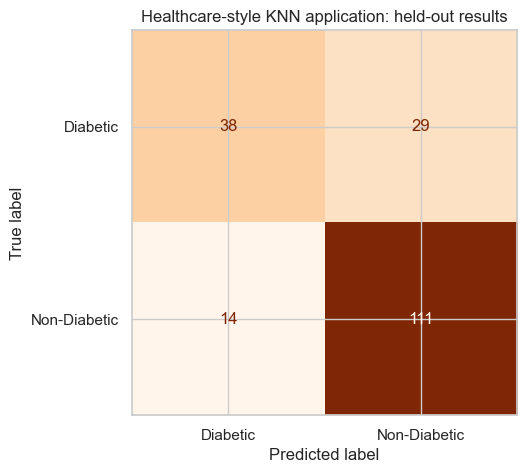

In [10]:
diabetes_rows = []
diabetes_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for weight_rule in ["uniform", "distance"]:
    diabetes_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights=weight_rule))
    scores = cross_val_score(diabetes_model, diabetes_X_train, diabetes_y_train, cv=diabetes_cv, scoring="balanced_accuracy", error_score="raise")
    diabetes_rows.append({"weights": weight_rule, "mean_balanced_accuracy": scores.mean(), "std_balanced_accuracy": scores.std()})
diabetes_results = pd.DataFrame(diabetes_rows)
display(diabetes_results.round(3))

selected_weight = diabetes_results.loc[diabetes_results["mean_balanced_accuracy"].idxmax(), "weights"]
diabetes_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights=selected_weight))
diabetes_model.fit(diabetes_X_train, diabetes_y_train)
diabetes_prediction = diabetes_model.predict(diabetes_X_test)
display(pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "macro_f1"],
    "test_value": [
        accuracy_score(diabetes_y_test, diabetes_prediction),
        balanced_accuracy_score(diabetes_y_test, diabetes_prediction),
        f1_score(diabetes_y_test, diabetes_prediction, average="macro", zero_division=0),
    ],
}).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(diabetes_y_test, diabetes_prediction, cmap="Oranges", colorbar=False, ax=ax)
ax.set_title("Healthcare-style KNN application: held-out results")
plt.show()

## ۷. مثال به‌سبک سلامت: معیارها و احتیاط

دادهٔ diabetes اندازه‌گیری‌های عددی مرتبط با سلامت و برچسب دودویی دارد. سطرها و نوع‌ها پیش از برازش بررسی می‌شوند. این نوت‌بوک فقط مثال برنامه‌نویسی است. نباید برای تشخیص پزشکی به‌کار رود و سامانهٔ بالینی به اعتبارسنجی بیرونی، احتمال‌های کالیبره، تحلیل انصاف، نظارت پزشکی و شواهد روشن از مناسب‌بودن هدف و ویژگی نیاز دارد.

برای موقعیت نامتوازن یا حساس به هزینه، دقت معمولی کامل نیست. balanced accuracy به recall هر کلاس وزن برابر می‌دهد و macro F1 precision و recall را در کلاس‌ها ترکیب می‌کند. مقایسهٔ وزن‌های uniform و distance آزمایش انتخاب مدل در foldهای آموزش است؛ ماتریس درهم‌ریختگی کنارگذاشته‌شده الگوی خطا را به‌جای پنهان‌کردن در یک عدد نشان می‌دهد.

## ۸. چالش‌ها فراتر از امتیاز

سامانه‌های مبتنی بر شباهت چند خطر تکراری دارند:

1. نمایش: ویژگی نامرتبط، بدون مقیاس یا proxy فاصله را مخدوش می‌کند.
2. همسایگی تنک: نزدیک‌ترین مثال‌ها نیز ممکن است دور باشند.
3. Drift: کاربر، مکان، محصول یا فرایند اندازه‌گیری جدید معنای همسایگی را عوض می‌کند.
4. جانبداری و انصاف: برچسب تاریخی و proxy جمعیت‌شناختی می‌توانند نتیجهٔ نابرابر را تکرار کنند.
5. حریم خصوصی: مدل مبتنی بر نمونه، مثال‌های آموزش را نگه می‌دارد و شاید اطلاعات حساس را آشکار کند.
6. تفسیرپذیری: فهرست همسایه شهودی است، اما علیت را اثبات نمی‌کند.
7. عملیات: حافظه و زمان پرس‌وجو با دادهٔ ذخیره‌شده رشد می‌کنند.
8. ارزیابی: تقسیم تصادفی ممکن است وقتی زمان، گروه یا مکان وابستگی می‌سازند عملکرد را بیش‌برآورد کند.

کار مسئولانه با KNN، اعتبارسنجی فنی و بازبینی دامنه را ترکیب می‌کند. وقتی تقسیم تصادفی با استقرار مطابق نیست، تقسیم آگاه از زمان، گروه یا جغرافیا را در نظر بگیرید. پس از انتشار کیفیت داده و عملکرد را پایش کنید و برای نبود همسایهٔ قابل اعتماد fallback تعریف کنید.

## ۹. تمرین‌ها و جمع‌بندی

1. province را با ویژگی مکانی دیگر عوض و منحنی اعتبارسنجی را مقایسه کنید.
2. با کنارگذاشتن یک province تقسیم group-aware بسازید و آن را با تقسیم تصادفی مقایسه کنید.
3. فقط پس از طراحی نمایش متن و فاصلهٔ موجه، ویژگی متن دسته را اضافه کنید.
4. برای diabetes، K را تغییر و balanced accuracy، macro F1 و ماتریس درهم‌ریختگی را مقایسه کنید.
5. قانون abstention بسازید که وقتی فاصلهٔ نزدیک‌ترین همسایه از percentile انتخاب‌شده بالاتر است پرس‌وجو را علامت‌گذاری کند.

### جمع‌بندی

کاربرد KNN زمانی موفق است که فاصله رابطهٔ محلی مفیدی را بگیرد و سامانه توان ذخیره و جست‌وجوی مثال‌ها را داشته باشد. مثال جغرافیایی رستوران را ساختیم، کیفیت داده را دیدیم، K را بدون نشت آزمون انتخاب کردیم، همسایه‌های محلی را تفسیر کردیم و چالش زمان پیش‌بینی را سنجیدیم. سپس دادهٔ به‌سبک سلامت را برای تأکید بر ارزیابی متوازن و احتیاط به‌کار بردیم. موفقیت عملی KNN به اندازهٔ فراخوانی طبقه‌بند به نمایش، طراحی اعتبارسنجی، عملیات، اخلاق و پایش پیوسته وابسته است.